# D-Soil Lab Triaxial Test Kratos Notebook

This notebook runs a **triaxial test** with the provided local input files and Kratos GeoMechanicsApplication.

It follows this workflow:
1. Locate the existing case input files (`ProjectParameters.json`, `MaterialParameters.json`, `mesh.mdpa`).
2. Run a Kratos simulation with those input files.
3. Read the simulation output (displacements, stresses, strains).
4. Plot the triaxial response (stress-strain, volumetric strain, stress paths, Mohr's circle).


## Requirements

Run this notebook from the `triaxial_test` folder (or any parent folder) in a Python kernel that has:
- `KratosMultiphysics` + `KratosGeoMechanicsApplication`
- `matplotlib` and `numpy`
For installation of the wheels and setup, see [Getting Started](../../getting_started.md).

### Notes

- This notebook uses local files in `triaxial_test` only; it has no `D-Soil Lab` dependency. For trying out the `D-Soil Lab` tool navigate to: https://dsoillab.deltares.nl/
- It runs Kratos directly with the local `ProjectParameters.json`, `MaterialParameters.json`, and `mesh.mdpa` input files, unmodified. You can modify these input files with your desired inputs.


## Mohr-Coulomb material inputs (quick guide)

The values used in this test are:

| Parameter | Value |
| --- | --- |
| `YOUNG_MODULUS` | `2.0e+04` kPa |
| `POISSON_RATIO` | `0.25` |
| `GEO_COHESION` | `5.0` kPa |
| `GEO_FRICTION_ANGLE` | `25.0` deg |
| `GEO_ENABLE_TENSION_CUT_OFF` | `true` |
| `GEO_TENSILE_STRENGTH` | `0.0` kPa |
| `GEO_DILATANCY_ANGLE` | `2.0` deg |

Tip: keep units consistent with the rest of the input deck (this triaxial example uses kPa-scale stresses).


## Triaxial boundary-condition inputs: cell pressure and axial strain

This case applies triaxial loading through two boundary-condition processes in ProjectParameters.json. Their time histories come from tables defined in mesh.mdpa.

### 1) Initial effective cell pressure (confining pressure)

Python process configuration:
```python
python_module: apply_normal_load_table_process
model_part_name: PorousDomain.Lateral_load
variable_name: NORMAL_CONTACT_STRESS
table: [1, 0]
```

Corresponding table from mesh.mdpa:

| Table 1 | TIME | NORMAL_CONTACT_STRESS |
| --- | ---: | ---: |
| 1 | -0.01 | 100.0 |
| 1 | 0.0 | 100.0 |
| 1 | 1.0 | 100.0 |

So the confining pressure is constant at 100 (kPa in this example unit system) over the full simulation.

### 2) Maximum axial strain applied to the specimen

Python process configuration:
```python
python_module: apply_vector_constraint_table_process
model_part_name: PorousDomain.Top_displacement
variable_name: DISPLACEMENT
active: [false, true, false] (Y-direction only)
table: [0, 2, 0]
```

Corresponding table from mesh.mdpa:

| Table 2 | TIME | DISPLACEMENT_Y |
| --- | ---: | ---: |
| 2 | -0.01 | 0.0 |
| 2 | 0.0 | 0.0 |
| 2 | 1.0 | -0.2000 |

The final imposed top displacement is -0.2. With an initial specimen height of 1.0m (from node coordinates), the nominal axial strain magnitude is about 0.2 (20 percent), compressive by sign convention.

In short: both triaxial control inputs are passed through mesh.mdpa tables, not hard-coded directly in the process values.


In [1]:
from contextlib import contextmanager
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np

import KratosMultiphysics as Kratos
from KratosMultiphysics.GeoMechanicsApplication.geomechanics_analysis import GeoMechanicsAnalysis
from KratosMultiphysics.GeoMechanicsApplication.gid_output_file_reader import GiDOutputFileReader

In [2]:
REQUIRED_CASE_FILES = [
    "ProjectParameters.json",
    "MaterialParameters.json",
    "mesh.mdpa"
]

def find_case_directory(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    relative_candidates = [
        Path("."),
        Path("triaxial_test"),
        Path("kratos-docs/docs/examples/triaxial_test"),
        Path("docs/examples/triaxial_test"),
    ]

    for base in [current, *current.parents]:
        for relative_candidate in relative_candidates:
            candidate = (base / relative_candidate).resolve()
            if all((candidate / file_name).exists() for file_name in REQUIRED_CASE_FILES):
                return candidate
    raise FileNotFoundError(
        "Could not locate triaxial_test folder with all required input files."
    )

CASE_DIR = find_case_directory()
PROJECT_PARAMETERS_FILE = CASE_DIR / "ProjectParameters.json"
OUTPUT_FILE = CASE_DIR / "triaxial_test_output.post.res"

print(f"Using triaxial case directory: {CASE_DIR}")

Using triaxial case directory: C:\Checkouts\Deltares\Kratos-GeoMechanicsApplication-Documentation\kratos-docs\docs\examples\triaxial_test


In [3]:
@contextmanager
def working_directory(path: Path):
    previous_directory = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous_directory)


def run_kratos_case(project_parameters_file: Path):
    model = Kratos.Model()
    with working_directory(project_parameters_file.parent):
        with project_parameters_file.open("r", encoding="utf-8") as parameter_file:
            parameters = Kratos.Parameters(parameter_file.read())

        analysis = GeoMechanicsAnalysis(model, parameters)
        analysis.Run()
    return model


model = run_kratos_case(PROJECT_PARAMETERS_FILE)
print(f"Kratos run completed. Output file: {OUTPUT_FILE}")


Kratos run completed. Output file: C:\Checkouts\Deltares\Kratos-GeoMechanicsApplication-Documentation\kratos-docs\docs\examples\triaxial_test\triaxial_test_output.post.res


In [4]:
reader = GiDOutputFileReader()
output_data = reader.read_output_from(OUTPUT_FILE)
times = reader.get_time_steps_from_first_valid_result(output_data)
final_time = times[-1] if times else 1.0


In [5]:
def _flatten_ip_values(values):
    flat = []
    for element_values in values:
        for ip_value in element_values:
            flat.append(ip_value)
    return flat


def _read_gp_values(reader, output_data, variable_name, query_time):
    if hasattr(reader, "gauss_point_values_at_time"):
        return reader.gauss_point_values_at_time(variable_name, query_time, output_data)
    if hasattr(reader, "element_integration_point_values_at_time"):
        return reader.element_integration_point_values_at_time(variable_name, query_time, output_data)
    raise AttributeError("No supported gauss-point extraction method found on GiDOutputFileReader")


stress_values = _read_gp_values(reader, output_data, "CAUCHY_STRESS_TENSOR", final_time)
strain_values = _read_gp_values(reader, output_data, "ENGINEERING_STRAIN_TENSOR", final_time)
flat_stress = _flatten_ip_values(stress_values)
flat_strain = _flatten_ip_values(strain_values)


In [6]:
mean_stress = []
deviatoric_q = []
axial_strain = []

for stress_tensor, strain_tensor in zip(flat_stress, flat_strain):
    s_xx, s_yy, s_zz, *_ = stress_tensor
    e_xx, e_yy, e_zz, *_ = strain_tensor

    p = (s_xx + s_yy + s_zz) / 3.0
    q = s_yy - s_xx
    mean_stress.append(p)
    deviatoric_q.append(q)
    axial_strain.append(e_yy)


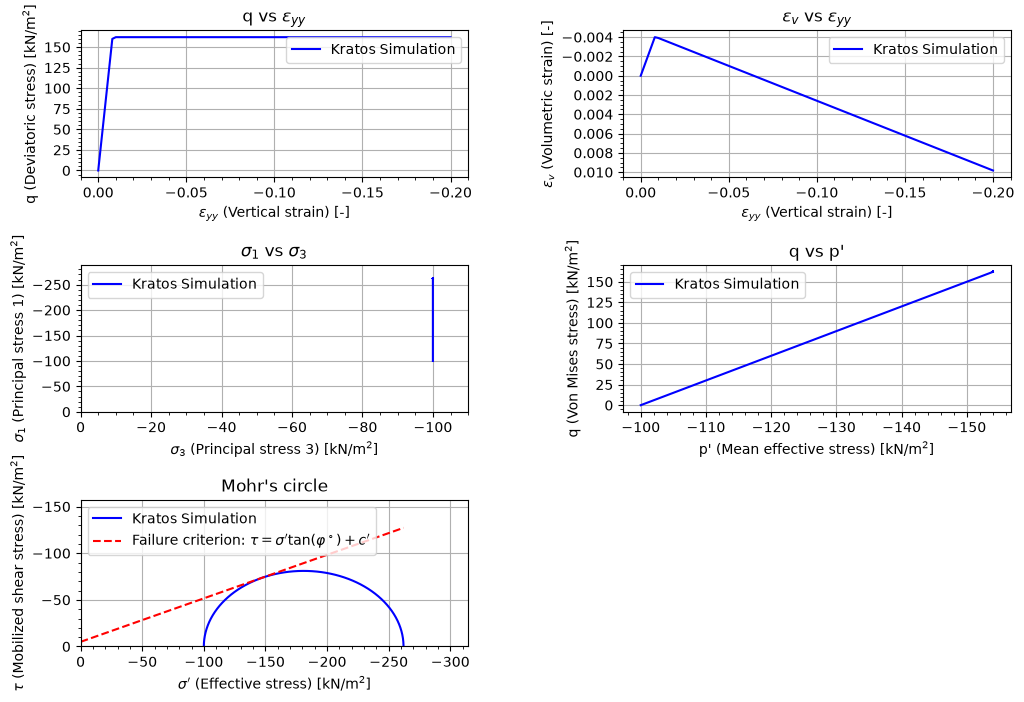

In [ ]:
import json

def _mean_ip_component(ip_values, index):
    return float(np.mean([row[index] for row in ip_values]))


def _read_mdpa_table(mdpa_path: Path, table_id: int):
    lines = mdpa_path.read_text(encoding="utf-8").splitlines()
    header = f"Begin Table {table_id} "
    start = None
    for i, line in enumerate(lines):
        if line.startswith(header):
            start = i + 1
            break
    if start is None:
        raise ValueError(f"Table {table_id} not found in {mdpa_path.name}")

    times = []
    values = []
    for line in lines[start:]:
        stripped = line.strip()
        if stripped == "End Table":
            break
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) >= 2:
            times.append(float(parts[0]))
            values.append(float(parts[1]))

    if not times:
        raise ValueError(f"Table {table_id} in {mdpa_path.name} is empty")
    return np.array(times, dtype=float), np.array(values, dtype=float)


def _build_triaxial_path_from_output(output_file: Path, mdpa_path: Path):
    reader = GiDOutputFileReader()
    output_data = reader.read_output_from(output_file)
    times = reader.get_time_steps_from_first_valid_result(output_data)
    if not times:
        raise ValueError("No result time steps found in GiD output for plotting")
    times = np.array(times, dtype=float)

    t_disp, disp_y_table = _read_mdpa_table(mdpa_path, table_id=2)

    yy = np.interp(times, t_disp, disp_y_table) * 100.0  # height = 1.0 m

    vol_list = []
    p_list = []
    q_list = []
    sigma1_list = []
    sigma3_list = []
    for query_time in times:
        stress_values = _read_gp_values(reader, output_data, "CAUCHY_STRESS_TENSOR", query_time)
        strain_values = _read_gp_values(reader, output_data, "ENGINEERING_STRAIN_TENSOR", query_time)
        mean_stress_values = _read_gp_values(reader, output_data, "MEAN_EFFECTIVE_STRESS", query_time)
        von_mises_values = _read_gp_values(reader, output_data, "VON_MISES_STRESS", query_time)
        flat_stress_t = _flatten_ip_values(stress_values)
        flat_strain_t = _flatten_ip_values(strain_values)
        flat_mean_stress_t = _flatten_ip_values(mean_stress_values)
        flat_von_mises_t = _flatten_ip_values(von_mises_values)

        s_yy = _mean_ip_component(flat_stress_t, 1)
        s_xx = _mean_ip_component(flat_stress_t, 0)

        # Kratos uses a tension-positive sign convention, so the compressive
        # stresses in this triaxial test come out negative, as in the raw output.
        sigma1_list.append(s_yy)  # axial stress (more compressive => more negative)
        sigma3_list.append(s_xx)  # radial/confining stress (less compressive)

        p_list.append(float(np.mean(flat_mean_stress_t)))
        q_list.append(float(np.mean(flat_von_mises_t)))

        vol_list.append(
            100.0 * float(np.mean([row[0] + row[1] + row[2] for row in flat_strain_t]))
        )

    p = np.array(p_list, dtype=float)
    q = np.array(q_list, dtype=float)
    vol = np.array(vol_list, dtype=float)
    sigma1 = np.array(sigma1_list, dtype=float)
    sigma3 = np.array(sigma3_list, dtype=float)

    return yy, vol, sigma1, sigma3, p, q


mdpa_path = CASE_DIR / "mesh.mdpa"
yy, vol, sigma1, sigma3, p_list, q_list = _build_triaxial_path_from_output(OUTPUT_FILE, mdpa_path)

# Read Mohr-Coulomb strength parameters for failure line plotting.
with (CASE_DIR / "MaterialParameters.json").open("r", encoding="utf-8") as material_file:
    material_data = json.load(material_file)
material_variables = material_data["properties"][0]["Material"]["Variables"]
cohesion = float(material_variables["GEO_COHESION"])
phi = float(material_variables["GEO_FRICTION_ANGLE"])

fig = plt.figure(figsize=(12, 8))
grid = fig.add_gridspec(3, 2, hspace=0.6, wspace=0.4)

# 0: |sigma1-sigma3| vs e_yy
ax1 = fig.add_subplot(grid[0, 0])
ax1.plot(yy/100.0, q_list, "-", color="blue", label="Kratos Simulation")
ax1.set_title(r"q vs $\varepsilon_{yy}$")
ax1.set_xlabel(r"$\varepsilon_{yy}$ (Vertical strain) [-]")
ax1.set_ylabel(r"q (Deviatoric stress) [kN/m$^2$]")
ax1.grid(True)
ax1.invert_xaxis()
ax1.locator_params(nbins=8)
ax1.minorticks_on()
ax1.legend()

# 1: e_v vs e_yy
ax2 = fig.add_subplot(grid[0, 1])
ax2.plot(yy/100.0, vol/100.0, "-", color="blue", label="Kratos Simulation")
ax2.set_title(r"$\varepsilon_v$ vs $\varepsilon_{yy}$")
ax2.set_xlabel(r"$\varepsilon_{yy}$ (Vertical strain) [-]")
ax2.set_ylabel(r"$\varepsilon_v$ (Volumetric strain) [-]")
ax2.grid(True)
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.locator_params(nbins=8)
ax2.minorticks_on()
ax2.legend()

# 2: sigma1 vs sigma3
ax3 = fig.add_subplot(grid[1, 0])
ax3.plot(sigma3, sigma1, "-", color="blue", label="Kratos Simulation")
ax3.set_title(r"$\sigma_1$ vs $\sigma_3$")
ax3.set_xlabel(r"$\sigma_3$ (Principal stress 3) [kN/m$^2$]")
ax3.set_ylabel(r"$\sigma_1$ (Principal stress 1) [kN/m$^2$]")
ax3.grid(True)
ax3.locator_params(nbins=8)

min_val_x = float(np.min(sigma3))
min_val_y = float(np.min(sigma1))
padding_x = 0.1 * (0.0 - min_val_x) if min_val_x < 0.0 else 1.0
padding_y = 0.1 * (0.0 - min_val_y) if min_val_y < 0.0 else 1.0
ax3.set_xlim(0.0, min_val_x - padding_x)
ax3.set_ylim(0.0, min_val_y - padding_y)
ax3.minorticks_on()
ax3.legend()

# 3: p' vs q
ax4 = fig.add_subplot(grid[1, 1])
ax4.plot(p_list, q_list, "-", color="blue", label="Kratos Simulation")
ax4.set_title(r"q vs p'")
ax4.set_xlabel(r"p' (Mean effective stress) [kN/m$^2$]")
ax4.set_ylabel(r"q (Von Mises stress) [kN/m$^2$]")
ax4.grid(True)
ax4.invert_xaxis()
ax4.locator_params(nbins=8)
ax4.minorticks_on()
ax4.legend()

# 4: Mohr circle
ax5 = fig.add_subplot(grid[2, 0])
sigma_1_end = float(sigma1[-1])
sigma_3_end = float(sigma3[-1])
center = (sigma_1_end + sigma_3_end) / 2.0
radius = abs(sigma_1_end - sigma_3_end) / 2.0
theta = np.linspace(0.0, np.pi, 200)
sigma = center + radius * np.cos(theta)
tau = -radius * np.sin(theta)
ax5.plot(sigma, tau, label="Kratos Simulation", color="blue")

phi_rad = np.radians(phi)
x_line = np.linspace(0.0, sigma_1_end, 200)
y_line = x_line * np.tan(phi_rad) - cohesion
ax5.plot(
    x_line,
    y_line,
    "r--",
    label=r"Failure criterion: $\tau = \sigma' \tan(\varphi^\circ) + c'$",
)

ax5.set_title("Mohr's circle")
ax5.set_xlabel(r"$\sigma'$ (Effective stress) [kN/m$^2$]")
ax5.set_ylabel(r"$\tau$ (Mobilized shear stress) [kN/m$^2$]")
ax5.grid(True)
ax5.set_xlim(left=0.0, right=1.2 * float(np.min(sigma1)))
ax5.set_ylim(bottom=0.0, top=0.6 * float(np.min(sigma1)))
ax5.minorticks_on()
ax5.legend(loc="upper left")

# Empty panel to match 5-plot layout.
ax6 = fig.add_subplot(grid[2, 1])
ax6.axis("off")

plt.show()
